Device: cuda
CSV loaded: 671 rows
Found 611 skull-stripped (_11) patient folders

Total patients loaded:  611
Skipped (Not in CSV):   0
Skipped (Missing MRI):  0


C:\Users\Nishk\anaconda3\Lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


SwinUNETR loaded — epoch 97, Val Dice 0.8846
Classifier loaded — trained epoch 46, best val loss 0.7491

Building cache for 611 patients...


100%|██████████| 611/611 [1:10:17<00:00,  6.90s/it]



Running inference on 611 patients...


100%|██████████| 611/611 [00:12<00:00, 49.33it/s]



   UPENN-GBM EXTERNAL VALIDATION RESULTS

IDH Status (n=611)
  Accuracy : 0.7823
  F1 Score : 0.0567
  AUC      : 0.5086

MGMT Methylation (n=289)
  Accuracy : 0.5467
  F1 Score : 0.6932
  AUC      : 0.4526

ROC curves saved to upenn_roc_curves.png
NOTE: Grade head not evaluated — all UPENN patients are GBM


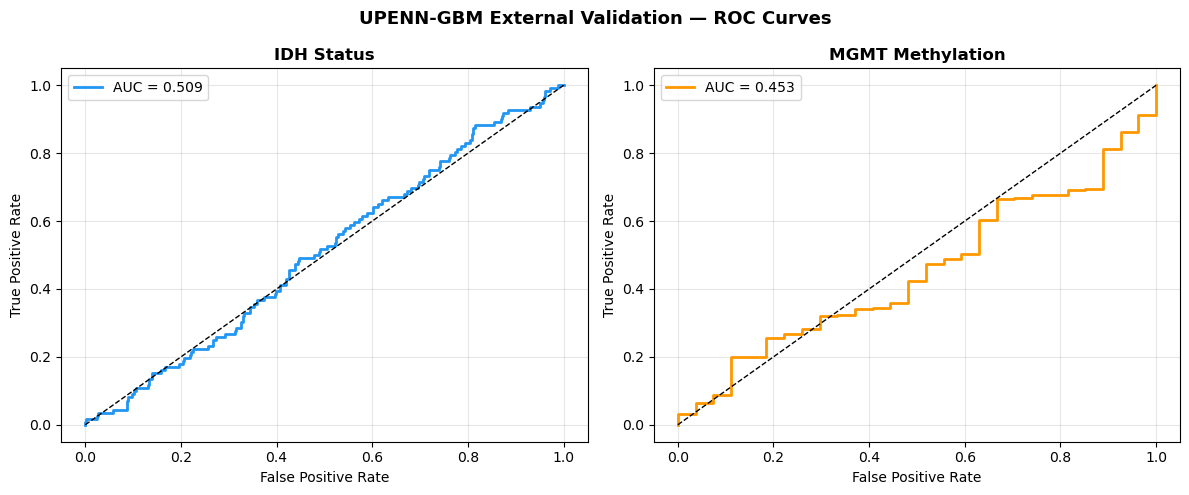

In [1]:
import os

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from scipy import ndimage
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve
import matplotlib.pyplot as plt

from monai.networks.nets import SwinUNETR
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, Spacingd, NormalizeIntensityd,
    ConcatItemsd, CropForegroundd, ResizeWithPadOrCropd, ToTensord
)
from monai.data import Dataset, DataLoader

# ==========================================
# 1. CONFIGURATION
# ==========================================
# FIXED PATH: Pointing exactly to where the patient folders are
NIFTI_DIR       = r"D:\UPENN\PKG - UPENN-GBM-NIfTI\UPENN-GBM\NIfTI-files\images_structural"
SEG_DIR         = r"D:\UPENN\PKG - UPENN-GBM-NIfTI\UPENN-GBM\NIfTI-files\automated_segm"
UPENN_CSV       = r"D:\UPENN\UPENN-GBM_clinical_info_v2.1.csv"
CACHE_DIR       = r"C:\Users\Nishk\Documents\Internship\25-06-2026\Model Checkpoints\Feature_Cache\upenn_feature_cache"
SWIN_CKPT       = r"C:\Users\Nishk\Documents\Internship\25-06-2026\Model Checkpoints\swinunetr_ucsf_finetuned.pt"
CLF_CKPT        = r"C:\Users\Nishk\Documents\Internship\25-06-2026\Model Checkpoints\clf_best_D.pth"

DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SPATIAL_SIZE    = (128, 128, 128)
VOXEL_SPACING   = (1.0, 1.0, 1.0)
SEG_THRESHOLD   = 0.3
TTA_RUNS        = 5

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
invalid_vals = ["not available", "na", "nan", "", "unknown", "n/a"]

def map_idh(x):
    x = str(x).strip().lower()
    if x in invalid_vals: return float('nan')
    return 0.0 if 'wildtype' in x else 1.0

def map_mgmt(x):
    x = str(x).strip().lower()
    if x in invalid_vals: return float('nan')
    return 1.0 if 'methylated' in x else 0.0

def map_sex(x):
    x = str(x).strip().upper()
    return 0.0 if x in ['M', 'MALE'] else 1.0

def extract_encoder_features(model, image_tensor):
    with torch.no_grad():
        x = image_tensor.unsqueeze(0).to(DEVICE)
        hidden_states = model.swinViT(x)
        bottleneck = hidden_states[4]               # [1, 768, 4, 4, 4]
        features   = bottleneck.mean(dim=[2,3,4])   # [1, 768]
    return features.squeeze(0).cpu()                # [768]

def tta_predict(model, image_tensor, n_runs=TTA_RUNS):
    model.eval()
    preds = []
    with torch.no_grad():
        for _ in range(n_runs):
            aug = image_tensor.clone()
            flipped_axes = []
            for axis in [1, 2, 3]:
                if torch.rand(1).item() > 0.5:
                    aug = torch.flip(aug, dims=[axis])
                    flipped_axes.append(axis)
            aug    = aug + (torch.rand(1).item() - 0.5) * 0.2
            logits = model(aug.unsqueeze(0).to(DEVICE))
            probs  = torch.sigmoid(logits).squeeze(0).cpu()
            for axis in reversed(flipped_axes):
                probs = torch.flip(probs, dims=[axis])
            preds.append(probs)
    
    stack     = torch.stack(preds, dim=0)
    mean_pred = stack.mean(dim=0)
    variance  = stack.var(dim=0).mean(0, keepdim=True)
    vmin, vmax = variance.min(), variance.max()
    norm_var  = (variance - vmin) / (vmax - vmin + 1e-8)
    return mean_pred, 1.0 - norm_var, norm_var

def extract_morphological_features(mean_pred):
    et    = (mean_pred[0] > SEG_THRESHOLD).numpy().astype(np.float32)
    tc    = (mean_pred[1] > SEG_THRESHOLD).numpy().astype(np.float32)
    wt    = (mean_pred[2] > SEG_THRESHOLD).numpy().astype(np.float32)
    edema = np.clip(wt - tc, 0, 1)

    tumor_vol = float(wt.sum())
    core_vol  = float(tc.sum())
    edema_vol = float(edema.sum())
    enh_vol   = float(et.sum())
    edema_core_ratio = edema_vol / (core_vol + 1e-6)

    eroded  = ndimage.binary_erosion(wt.astype(bool))
    surface = wt.astype(bool) & ~eroded
    sa      = float(surface.sum())
    
    compactness = tumor_vol / (sa ** 1.5 + 1e-6) if sa > 0 else 0.0
    sphericity  = ((np.pi ** (1/3) * (6 * tumor_vol) ** (2/3)) / (sa + 1e-6) if (sa > 0 and tumor_vol > 0) else 0.0)

    return {
        'tumor_volume':     tumor_vol,
        'core_volume':      core_vol,
        'edema_volume':     edema_vol,
        'enhancing_volume': enh_vol,
        'edema_core_ratio': edema_core_ratio,
        'surface_area':     sa,
        'compactness':      compactness,
        'sphericity':       sphericity,
    }

def morphology_to_tensor(d):
    t = torch.tensor(list(d.values()), dtype=torch.float32)
    t = torch.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0)
    t[:4] = torch.log1p(t[:4])       # log compress volumes
    t[5]  = torch.log1p(t[5])        # log compress surface area
    t[4]  = torch.clamp(t[4], 0, 10) # edema_core_ratio
    t[6]  = torch.clamp(t[6], 0, 10) # compactness
    t[7]  = torch.clamp(t[7], 0, 2)  # sphericity
    return t

# ==========================================
# 3. MODEL DEFINITIONS
# ==========================================
class ConfidenceGatedFusion(nn.Module):
    def __init__(self, encoder_dim=768, morph_dim=10, fused_dim=512, mode='D'):
        super().__init__()
        self.mode = mode
        self.encoder_proj = nn.Sequential(
            nn.Linear(encoder_dim, fused_dim),
            nn.ReLU(), nn.Dropout(0.3),
        )
        self.morph_proj = nn.Sequential(
            nn.Linear(morph_dim, 256),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, fused_dim),
        )
        self.morph_gate = nn.Linear(morph_dim, fused_dim)

    def forward(self, encoder_features, morph_features, confidence_score):
        enc   = self.encoder_proj(encoder_features)
        morph = self.morph_proj(morph_features)
        conf  = confidence_score.view(-1, 1)
        morph_gate = torch.sigmoid(self.morph_gate(morph_features))
        G = conf * morph_gate
        return G * enc + (1.0 - G) * morph

class BrainTumorClassifier(nn.Module):
    def __init__(self, encoder_dim=768, morph_dim=10, fused_dim=512, dropout=0.4):
        super().__init__()
        self.fusion = ConfidenceGatedFusion(encoder_dim, morph_dim, fused_dim)
        self.shared = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(), nn.Dropout(dropout),
        )
        self.head_idh   = nn.Linear(256, 1)
        self.head_grade = nn.Linear(256, 1)
        self.head_mgmt  = nn.Linear(256, 1)

    def forward(self, encoder_features, morph_features, confidence_score):
        fused  = self.fusion(encoder_features, morph_features, confidence_score)
        shared = self.shared(fused)
        return {
            'idh':   self.head_idh(shared),
            'grade': self.head_grade(shared),
            'mgmt':  self.head_mgmt(shared),
        }

# ==========================================
# 4. MAIN EXECUTION BLOCK (Required for Windows Dataloader)
# ==========================================
# ==========================================
# 4. MAIN EXECUTION BLOCK (Required for Windows Dataloader)
# ==========================================
# ==========================================
# 4. MAIN EXECUTION BLOCK (Required for Windows Dataloader)
# ==========================================
# ==========================================
# 4. MAIN EXECUTION BLOCK (Required for Windows Dataloader)
# ==========================================
if __name__ == '__main__':
    print(f"Device: {DEVICE}")

    # Load Clinical Data
    df = pd.read_csv(UPENN_CSV)
    df['ID'] = df['ID'].astype(str).str.strip() # Strip any hidden spaces
    print(f"CSV loaded: {len(df)} rows")

    upenn_dicts = []
    skipped_csv = 0
    skipped_modality = 0

    # Using the correct structural images folder
    patient_folders = sorted(glob.glob(os.path.join(NIFTI_DIR, "UPENN-GBM-*_11")))
    print(f"Found {len(patient_folders)} skull-stripped (_11) patient folders")

    for i, folder in enumerate(patient_folders):
        folder_name = os.path.basename(folder)   # EXACT MATCH: 'UPENN-GBM-00001_11'
        pid         = folder_name                # Keep the _11 suffix!

        # 1. Match CSV
        row = df[df['ID'] == pid]
        
        if row.empty:
            skipped_csv += 1
            continue
            
        row = row.iloc[0]

        # 2. Match Files (The files also use the _11 suffix)
        t1    = glob.glob(os.path.join(folder, f"{pid}_T1.nii.gz"))
        t1c   = glob.glob(os.path.join(folder, f"{pid}_T1GD.nii.gz"))
        t2    = glob.glob(os.path.join(folder, f"{pid}_T2.nii.gz"))
        flair = glob.glob(os.path.join(folder, f"{pid}_FLAIR.nii.gz"))
        
        # The segmentation masks usually omit the _11 or structure it differently, 
        # but based on your earlier folder printout, they use the base ID:
        base_id = pid.split('_')[0] # 'UPENN-GBM-00001'
        seg   = glob.glob(os.path.join(SEG_DIR, f"{base_id}_automated_approx_segm.nii.gz"))

        if not all([t1, t1c, t2, flair]):
            skipped_modality += 1
            continue

        # Safely pull clinical vars (using .get() in case IDH/MGMT aren't in this specific CSV version)
        upenn_dicts.append({
            "patient_id": pid,
            "t1":    t1[0],
            "t1c":   t1c[0],
            "t2":    t2[0],
            "flair": flair[0],
            # Removed "seg" entirely to prevent DataLoader PyTorch crash
            "idh":   map_idh(row.get('IDH1', float('nan'))),
            "mgmt":  map_mgmt(row.get('MGMT', float('nan'))),
            "age":   float(row['Age_at_scan_years']) if pd.notna(row.get('Age_at_scan_years')) else 0.0,
            "sex":   map_sex(row.get('Gender', '')),
            "grade": float('nan'),   
        })

    print(f"\nTotal patients loaded:  {len(upenn_dicts)}")
    print(f"Skipped (Not in CSV):   {skipped_csv}")
    print(f"Skipped (Missing MRI):  {skipped_modality}")
    
    if len(upenn_dicts) == 0:
        print("\nCRITICAL ERROR: No patients loaded. Check paths!")
        import sys; sys.exit()

    # --- Rest of the code below remains exactly the same ---
    val_transforms = Compose([
        LoadImaged(keys=['t1','t1c','t2','flair']),
        EnsureChannelFirstd(keys=['t1','t1c','t2','flair']),
        ConcatItemsd(keys=['t1','t1c','t2','flair'], name='image'),
        Orientationd(keys=['image'], axcodes='RAS'),
        Spacingd(keys=['image'], pixdim=VOXEL_SPACING, mode='bilinear'),
        NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
        
        # ---> THE MISSING PIECE ADDED HERE <---
        CropForegroundd(keys=['image'], source_key='image'), 
        
        ResizeWithPadOrCropd(keys=['image'], spatial_size=SPATIAL_SIZE),
        ToTensord(keys=['image'])
    ])

    upenn_ds     = Dataset(data=upenn_dicts, transform=val_transforms)
    upenn_loader = DataLoader(upenn_ds, batch_size=1, shuffle=False, num_workers=2)
    
    # Load Models
    swin_model = SwinUNETR(in_channels=4, out_channels=3, feature_size=48, use_checkpoint=False).to(DEVICE)
    ckpt = torch.load(SWIN_CKPT, map_location=DEVICE, weights_only=False)
    swin_model.load_state_dict(ckpt['state_dict'])
    swin_model.eval()
    print(f"SwinUNETR loaded — epoch {ckpt['epoch']}, Val Dice {ckpt['val_dice']:.4f}")

    classifier = BrainTumorClassifier(encoder_dim=768, morph_dim=8, fused_dim=512, dropout=0.4).to(DEVICE)
    ckpt_clf   = torch.load(CLF_CKPT, map_location=DEVICE, weights_only=False)
    classifier.load_state_dict(ckpt_clf['model_state'])
    classifier.eval()
    print(f"Classifier loaded — trained epoch {ckpt_clf['epoch']}, best val loss {ckpt_clf['val_loss']:.4f}")

    # Build Cache
    os.makedirs(CACHE_DIR, exist_ok=True)
    print(f"\nBuilding cache for {len(upenn_dicts)} patients...")

    for step, batch_data in enumerate(tqdm(upenn_loader)):
        meta       = upenn_dicts[step]
        pid        = meta["patient_id"]
        cache_path = os.path.join(CACHE_DIR, f"{pid}.pt")

        if os.path.exists(cache_path):
            continue

        image = batch_data["image"].squeeze(0)  

        enc_feat = extract_encoder_features(swin_model, image)
        mean_pred, conf_map, _ = tta_predict(swin_model, image)
        conf_score = torch.tensor([conf_map.mean().item()])
        morph = morphology_to_tensor(extract_morphological_features(mean_pred))

        torch.save({
            "patient_id": pid,
            "encoder":    enc_feat,     
            "morph":      morph,        
            "conf_score": conf_score,   
            "idh":  torch.tensor([meta["idh"]],  dtype=torch.float32),
            "mgmt": torch.tensor([meta["mgmt"]], dtype=torch.float32),
            "grade": torch.tensor([float('nan')], dtype=torch.float32),
        }, cache_path)

        del image
        torch.cuda.empty_cache()

    # Inference Loop
    results = {"idh":  {"true": [], "prob": []}, "mgmt": {"true": [], "prob": []}}
    cache_files = sorted(glob.glob(os.path.join(CACHE_DIR, "*.pt")))
    print(f"\nRunning inference on {len(cache_files)} patients...")

    with torch.no_grad():
        for cf in tqdm(cache_files):
            data = torch.load(cf, map_location=DEVICE, weights_only=False)

            enc  = data["encoder"].unsqueeze(0).to(DEVICE)
            mor  = data["morph"].unsqueeze(0).to(DEVICE)
            conf = data["conf_score"].unsqueeze(0).to(DEVICE)

            out  = classifier(enc, mor, conf)

            for task in ["idh", "mgmt"]:
                label = data[task].item()
                if np.isnan(label):
                    continue
                prob = torch.sigmoid(out[task]).item()
                results[task]["true"].append(label)
                results[task]["prob"].append(prob)

    # Evaluation
    print("\n" + "="*50)
    print("   UPENN-GBM EXTERNAL VALIDATION RESULTS")
    print("="*50)

    for task, label_name in [("idh", "IDH Status"), ("mgmt", "MGMT Methylation")]:
        true  = np.array(results[task]["true"])
        probs = np.array(results[task]["prob"])
        
        if len(true) == 0:
            print(f"\n{label_name}: No evaluable patients")
            continue
            
        preds = (probs >= 0.5).astype(int)

        print(f"\n{label_name} (n={len(true)})")
        print(f"  Accuracy : {accuracy_score(true, preds):.4f}")
        print(f"  F1 Score : {f1_score(true, preds, zero_division=0):.4f}")
        if len(set(true)) > 1:
            auc = roc_auc_score(true, probs)
            print(f"  AUC      : {auc:.4f}")
        else:
            print(f"  AUC      : N/A (only one class present)")

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    colors = {"idh": "#2196F3", "mgmt": "#FF9800"}
    names  = {"idh": "IDH Status", "mgmt": "MGMT Methylation"}

    for ax, task in zip(axes, ["idh", "mgmt"]):
        true  = np.array(results[task]["true"])
        probs = np.array(results[task]["prob"])

        if len(true) > 0 and len(set(true)) > 1:
            fpr, tpr, _ = roc_curve(true, probs)
            auc = roc_auc_score(true, probs)
            ax.plot(fpr, tpr, color=colors[task], lw=2, label=f"AUC = {auc:.3f}")
        ax.plot([0,1],[0,1],'k--', lw=1)
        ax.set_title(f"{names[task]}", fontweight='bold')
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle("UPENN-GBM External Validation — ROC Curves", fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig("upenn_roc_curves.png", dpi=300, bbox_inches='tight')
    print("\nROC curves saved to upenn_roc_curves.png")
    print("NOTE: Grade head not evaluated — all UPENN patients are GBM")
    plt.show()